# Ground-truth coordinate alignment

This notebook reproduces the coordinate transformations used to align the field-measured ground-truth tree positions with the mobile laser scanning coordinate system.

The three scanner-derived datasets were already closely aligned with one another, so Jednoskenner is used as the reference coordinate system and only the ground-truth coordinates are transformed.

For each terrain, the workflow is:

1. standardise the GT and Jednoskenner coordinate columns.
2. centre the GT and scanner coordinates independently.
3. apply the terrain-specific coordinate reflection where required.
4. use two manually validated GT–Jednoskenner anchor correspondences to calculate the required rotation.
5. rotate the GT coordinates around the first GT anchor.
6. translate the transformed GT coordinates so that the first GT anchor coincides with the corresponding Jednoskenner anchor.
7. verify the transformation using the second anchor and the full spatial configuration.
No scaling is applied.

In [1]:
#Set up project paths and alignment input files


from pathlib import Path
import numpy as np
import pandas as pd


def find_project_root(start_path):
    """
    Find the main dissertation analysis folder.
    """

    start_path = Path(start_path).resolve()

    for folder in [
        start_path,
        *start_path.parents,
    ]:

        if (
            (folder / "data").is_dir()
            and
            (folder / "notebooks").is_dir()
        ):
            return folder

    raise FileNotFoundError(
        "Could not find the dissertation analysis folder."
    )


PROJECT_DIR = find_project_root(
    Path.cwd()
)


# Alignment input files
# The ground-truth coordinates are aligned to the Single sensor (Jednoskenner) coordinate system using matched anchor trees
# All three scanner datasets are loaded so that their positions can be compared together in the before/after alignment plots


alignment_inputs = {

    "Easy": {
        "GT":
            PROJECT_DIR
            / "data/raw/ground_truth/easy/20591171_e.xlsx",

        "Single sensor":
            PROJECT_DIR
            / "data/raw/3dfin/easy/"
            "20_20591171_n_e_jednoskenerovy_orezane.xlsx",

        "Dual sensor":
            PROJECT_DIR
            / "data/raw/3dfin/easy/"
            "20_20591171_n_e_dvojskener_orezane.xlsx",

        "Hovermap":
            PROJECT_DIR
            / "data/raw/3dfin/easy/"
            "20_20591171_n_e_hovermap_orezane.xlsx",
    },


    "Intermediate": {
        "GT":
            PROJECT_DIR
            / "data/raw/ground_truth/intermediate/20611471_i.xlsx",

        "Single sensor":
            PROJECT_DIR
            / "data/raw/3dfin/intermediate/"
            "10_20611471_n_int_jednoskener_orezane.xlsx",

        "Dual sensor":
            PROJECT_DIR
            / "data/raw/3dfin/intermediate/"
            "10_20611471_int_dvojskener_orezane.xlsx",

        "Hovermap":
            PROJECT_DIR
            / "data/raw/3dfin/intermediate/"
            "10_20611471_int_hovermap_orezane.xlsx",
    },


    "Challenging": {
        "GT":
            PROJECT_DIR
            / "data/raw/ground_truth/challenging"
            / "15_20531271_c.xlsx",

        "Single sensor":
            PROJECT_DIR
            / "data/raw/3dfin/challenging/"
            "15_20531271_n_ch_jednoskener_orezane.xlsx",

        "Dual sensor":
            PROJECT_DIR
            / "data/raw/3dfin/challenging/"
            "15_20531271_n_ch_dvojskener_orezane.xlsx",

        "Hovermap":
            PROJECT_DIR
            / "data/raw/3dfin/challenging/"
            "15_20531271_n_ch_hovermap_orezane.xlsx",
    },
}


# Check that all source files exist


for terrain, files in alignment_inputs.items():

    for source, path in files.items():

        if not path.exists():

            raise FileNotFoundError(
                f"Missing {terrain} {source} file: {path}"
            )


print(
    f"Project root: {PROJECT_DIR}"
)

print(
    "All alignment input files found."
)

Project root: /nfs/cfs/home2/zcap/zcapysa/geog0111/dissertation-analysis
All alignment input files found.


In [2]:
# Load and centre the coordinates used for alignment

def load_ground_truth(path):
    """
    Load the ground-truth tree coordinates and centre the X/Y values.
    """
    # Read the ground-truth Excel file
    gt = pd.read_excel(
        path,
        engine="openpyxl", 
    )
    
    # Keep only the tree ID and X/Y coordinate columns.
    # Rename them so that the same naming convention can be used
    # throughout the alignment workflow.
    
    gt = (
        gt[
            [
                "IDtree",
                "X_m",
                "Y_m",
            ]
        ]
        .rename(
            columns={
                "IDtree": "GT_ID",
                "X_m": "X",
                "Y_m": "Y",
            }
        )
        .copy()
    )

    # Convert the ID and coordinate columns to numeric values
    # Any values that cannot be converted are replaced with NaN and removed in the next step
    
    gt["GT_ID"] = pd.to_numeric(
        gt["GT_ID"],
        errors="coerce",
    )

    gt["X"] = pd.to_numeric(
        gt["X"],
        errors="coerce",
    )

    gt["Y"] = pd.to_numeric(
        gt["Y"],
        errors="coerce",
    )

    # Remove rows that do not contain a valid tree ID or both X and Y coordinates
    gt = gt.dropna(
        subset=[
            "GT_ID",
            "X",
            "Y",
        ]
    )
    # Tree IDs should be whole numbers
    gt["GT_ID"] = (
        gt["GT_ID"]
        .astype(int)
    )

    # Centre the GT coordinates by subtracting their mean position.
    #This removes the absolute coordinate offset and makes it easier to compare the relative spatial arrangement of the trees
    gt["X_centred"] = (
        gt["X"]
        - gt["X"].mean()
    )

    gt["Y_centred"] = (
        gt["Y"]
        - gt["Y"].mean()
    )

    return gt


def load_scanner_coordinates(path):
    """
    Load one 3DFin scanner dataset and centre the X/Y coordinates.
    """
    
    # Tree positions produced by 3DFin are stored in the Plot Metrics sheet
    # The first two rows contain additional header information so they are skipped when reading the table.
    
    scanner = pd.read_excel(
        path,
        sheet_name="Plot Metrics",
        engine="openpyxl",
        skiprows=2,
    )
    
    # Keep the tree label and X/Y position estimated by 3DFin
    # The original tree-label column has no useful Excel header so it is renamed here
    
    scanner = (
        scanner[
            [
                "Unnamed: 1",
                "X",
                "Y",
            ]
        ]
        .rename(
            columns={
                "Unnamed: 1": "Tree_label",
            }
        )
        .copy()
    )

    # 3DFin labels trees as T1, T2, T3, etc.
    # Extract the numeric part so that tree IDs are easier to work with
    
    scanner["Tree_ID"] = (
        scanner["Tree_label"]
        .astype(str)
        .str.extract(r"(\d+)")[0]
    )
    
    # Convert the extracted tree IDs and coordinates to numeric values.
    # Invalid values are converted to NaN and removed below.
    
    scanner["Tree_ID"] = pd.to_numeric(
        scanner["Tree_ID"],
        errors="coerce",
    )

    scanner["X"] = pd.to_numeric(
        scanner["X"],
        errors="coerce",
    )

    scanner["Y"] = pd.to_numeric(
        scanner["Y"],
        errors="coerce",
    )

    # Remove rows that cannot be used for spatial alignment
    scanner = scanner.dropna(
        subset=[
            "Tree_ID",
            "X",
            "Y",
        ]
    )

    scanner["Tree_ID"] = (
        scanner["Tree_ID"]
        .astype(int)
    )

    # Centre each scanner dataset independently around its own mean
    # This removes differences in absolute origin before the rotation and translation
    scanner["X_centred"] = (
        scanner["X"]
        - scanner["X"].mean()
    )

    scanner["Y_centred"] = (
        scanner["Y"]
        - scanner["Y"].mean()
    )

    return scanner



# Load the GT and scanner coordinates for each terrain


alignment_data = {}


for terrain, files in alignment_inputs.items():
    
    # Load the ground-truth coordinates for this terrain
    alignment_data[terrain] = {
        "GT":
            load_ground_truth(
                files["GT"]
            )
    }
    
    # Load the corresponding 3DFin tree coordinates from each of the three scanner datasets
    
    for scanner in [
        "Single sensor",
        "Dual sensor",
        "Hovermap",
    ]:

        alignment_data[terrain][scanner] = (
            load_scanner_coordinates(
                files[scanner]
            )
        )


# Check that the data loaded correctly

for terrain in [
    "Easy",
    "Intermediate",
    "Challenging",
]:

    print(f"\n{terrain}")

    gt = alignment_data[terrain]["GT"]
    
    # Report the number of usable GT trees after cleaning

    print(
        f"  GT:            {len(gt)} trees"
    )
    
    # Centred coordinates should have means very close to zero
    # A quick check that the centring step worked
    
    print(
        "  GT mean:       "
        f"X={gt['X_centred'].mean():.6f}, "
        f"Y={gt['Y_centred'].mean():.6f}"
    )

    for scanner in [
        "Single sensor",
        "Dual sensor",
        "Hovermap",
    ]:

        data = alignment_data[
            terrain
        ][scanner]
        
        # Check the number of trees loaded and that the centred X/Y means are approximately zero
        
        print(
            f"  {scanner:14s} "
            f"{len(data)} trees | "
            f"mean X={data['X_centred'].mean():.6f}, "
            f"Y={data['Y_centred'].mean():.6f}"
        )


Easy
  GT:            9 trees
  GT mean:       X=-0.000000, Y=0.000000
  Single sensor  9 trees | mean X=-0.000000, Y=-0.000000
  Dual sensor    9 trees | mean X=-0.000000, Y=0.000000
  Hovermap       9 trees | mean X=0.000000, Y=-0.000000

Intermediate
  GT:            22 trees
  GT mean:       X=0.000000, Y=0.000000
  Single sensor  23 trees | mean X=-0.000000, Y=0.000000
  Dual sensor    24 trees | mean X=0.000000, Y=0.000000
  Hovermap       25 trees | mean X=0.000000, Y=-0.000000

Challenging
  GT:            27 trees
  GT mean:       X=-0.000000, Y=-0.000000
  Single sensor  27 trees | mean X=0.000000, Y=0.000000
  Dual sensor    30 trees | mean X=-0.000000, Y=-0.000000
  Hovermap       30 trees | mean X=-0.000000, Y=0.000000


In [3]:
# Define the alignment settings for each terrain
# Two clearly matched trees are used as anchor points for each terrain
# They link the ground-truth (GT) tree IDs to the corresponding Single sensor (Jednoskenner) tree IDs
# For Easy and Challenging, the signs of both centred GT axes need to be reversed before rotation
#This is done so that the orientation matches the scanner coordinate system
# No reflection is for the Intermediate terrain.
# The rotation angle is not entered manually
# It is calculated in the next cell
# It is calculated from the direction between the two GT anchor trees and the direction between the corresponding scanner
# Only rigid transformations are used, so the coordinates are rotated and translated but not scaled

alignment_config = {

    "Easy": {
        "reflect_xy": True,
        "gt_anchor_1": 20,
        "gt_anchor_2": 21,
        "scanner_anchor_1": 8,
        "scanner_anchor_2": 9,
    },

    "Intermediate": {
        "reflect_xy": False,
        "gt_anchor_1": 1,
        "gt_anchor_2": 2,
        "scanner_anchor_1": 9,
        "scanner_anchor_2": 3,
    },

    "Challenging": {
        "reflect_xy": True,
        "gt_anchor_1": 29,
        "gt_anchor_2": 30,
        "scanner_anchor_1": 23,
        "scanner_anchor_2": 24,
    },
}



# Display the alignment decisions (check)


for terrain, config in alignment_config.items():
    
    # Set the text that will be printed for the reflection step
    reflection = (
        "reflect X and Y"
        if config["reflect_xy"]
        else "no reflection"
    )
    
    # Show the two GT-to-scanner anchor matches and whether coordinate reflection is applied for each terrain
    
    print(
        f"{terrain:13s} | "
        f"GT {config['gt_anchor_1']} → "
        f"Single T{config['scanner_anchor_1']}, "
        f"GT {config['gt_anchor_2']} → "
        f"Single T{config['scanner_anchor_2']} | "
        f"{reflection}"
    )

Easy          | GT 20 → Single T8, GT 21 → Single T9 | reflect X and Y
Intermediate  | GT 1 → Single T9, GT 2 → Single T3 | no reflection
Challenging   | GT 29 → Single T23, GT 30 → Single T24 | reflect X and Y


In [4]:
# Align the ground-truth coordinates to the Single sensor

def transform_ground_truth(
    gt,
    reference_scanner,
    config,
):
    """
    Align the centred ground-truth coordinates to the centred
    Single sensor (Jednoskenner) coordinate system.

    The transformation uses two manually matched anchor trees.
    Depending on the terrain, the GT coordinates are first
    reflected, then rotated so that the direction between the
    two GT anchors matches the direction between the two scanner
    anchors. Then the coordinates are shifted so that the
    first GT anchor sits exactly on the first scanner anchor.
    No scaling is applied.
    """

    # Work on a copy so the original GT table is not changed
    gt_out = gt.copy()



    # Prepare the centred GT coordinates
    
    # Reverse centred axes for Easy and Challenging Terrains before calulating the rotation
    if config["reflect_xy"]:

        gt_out["X_prepared"] = (
            -gt_out["X_centred"]
        )

        gt_out["Y_prepared"] = (
            -gt_out["Y_centred"]
        )

    else:
        # Intermediate already has the correct orientation so the centred coordinates can be used directly
        gt_out["X_prepared"] = (
            gt_out["X_centred"]
        )

        gt_out["Y_prepared"] = (
            gt_out["Y_centred"]
        )



    # Get the two matched GT and scanner anchor trees
    # Select the two GT trees chosen as clear reference matches
    
    gt_1 = (
        gt_out.loc[
            gt_out["GT_ID"]
            == config["gt_anchor_1"]
        ]
        .iloc[0]
    )

    gt_2 = (
        gt_out.loc[
            gt_out["GT_ID"]
            == config["gt_anchor_2"]
        ]
        .iloc[0]
    )
    # Select the corresponding trees from the reference scanner
    scanner_1 = (
        reference_scanner.loc[
            reference_scanner["Tree_ID"]
            == config["scanner_anchor_1"]
        ]
        .iloc[0]
    )

    scanner_2 = (
        reference_scanner.loc[
            reference_scanner["Tree_ID"]
            == config["scanner_anchor_2"]
        ]
        .iloc[0]
    )


    # Calculate the rotation needed for the alignment
    # Calculate the X/Y direction from GT anchor 1 to anchor 2
    gt_dx = (
        gt_2["X_prepared"]
        - gt_1["X_prepared"]
    )

    gt_dy = (
        gt_2["Y_prepared"]
        - gt_1["Y_prepared"]
    )
    
    # Do the same for the corresponding scanner anchors
    scanner_dx = (
        scanner_2["X_centred"]
        - scanner_1["X_centred"]
    )

    scanner_dy = (
        scanner_2["Y_centred"]
        - scanner_1["Y_centred"]
    )

    # Convert each anchor vector into an angle
    gt_angle = np.arctan2(
        gt_dy,
        gt_dx,
    )

    scanner_angle = np.arctan2(
        scanner_dy,
        scanner_dx,
    )

    # The difference between the two angles gives the amount that the GT coordinates need to be rotated
    rotation_rad = (
        scanner_angle
        - gt_angle
    )

    # Express the rotation within the usual -180 to +180 degree range
    rotation_rad = np.arctan2(
        np.sin(rotation_rad),
        np.cos(rotation_rad),
    )
    # Convert from radians to degrees for easier interpretation
    rotation_deg = np.degrees(
        rotation_rad
    )


    # Rotate all GT trees around the first GT anchor
    # Express every GT tree relative to anchor 1 before rotation
    x_relative = (
        gt_out["X_prepared"]
        - gt_1["X_prepared"]
    )

    y_relative = (
        gt_out["Y_prepared"]
        - gt_1["Y_prepared"]
    )

    # Calculate the values needed for the 2D rotation
    cos_theta = np.cos(
        rotation_rad
    )

    sin_theta = np.sin(
        rotation_rad
    )

    # Apply the 2D rotation to every GT tree
    x_rotated = (
        x_relative * cos_theta
        - y_relative * sin_theta
    )

    y_rotated = (
        x_relative * sin_theta
        + y_relative * cos_theta
    )


    # Move the rotated GT coordinates into the scanner frame
    # Add the position of scanner anchor 1 so that GT anchor 1 sits exactly on its corresponding scanner tree
    gt_out["X_aligned"] = (
        x_rotated
        + scanner_1["X_centred"]
    )

    gt_out["Y_aligned"] = (
        y_rotated
        + scanner_1["Y_centred"]
    )


    # Check how well the two anchor pairs align
    # Distance between the two GT anchors before alignment:
    gt_anchor_distance = np.sqrt(
        gt_dx ** 2
        + gt_dy ** 2
    )
    # Distance between the corresponding scanner anchors:
    scanner_anchor_distance = np.sqrt(
        scanner_dx ** 2
        + scanner_dy ** 2
    )

    # Get the aligned positions of both GT anchor trees
    transformed_1 = (
        gt_out.loc[
            gt_out["GT_ID"]
            == config["gt_anchor_1"]
        ]
        .iloc[0]
    )

    transformed_2 = (
        gt_out.loc[
            gt_out["GT_ID"]
            == config["gt_anchor_2"]
        ]
        .iloc[0]
    )


    # Anchor 1 should have an error of approximately zero because it is used as the fixed point for the final translation
    first_anchor_error = np.sqrt(
        (
            transformed_1["X_aligned"]
            - scanner_1["X_centred"]
        ) ** 2
        +
        (
            transformed_1["Y_aligned"]
            - scanner_1["Y_centred"]
        ) ** 2
    )
    
    # Anchor 2 may retain a small error because no scaling is used
    # If the GT and scanner anchor distances differ slightly,
    # both anchors cannot be made to overlap exactly using only rotation and translation
    
    second_anchor_error = np.sqrt(
        (
            transformed_2["X_aligned"]
            - scanner_2["X_centred"]
        ) ** 2
        +
        (
            transformed_2["Y_aligned"]
            - scanner_2["Y_centred"]
        ) ** 2
    )

    # Save the main alignment checks so they can be reviewed together
    diagnostics = {
        "Rotation_deg":
            rotation_deg,

        "GT_anchor_distance_m":
            gt_anchor_distance,

        "Scanner_anchor_distance_m":
            scanner_anchor_distance,

        "Anchor_distance_difference_m":
            scanner_anchor_distance
            - gt_anchor_distance,

        "First_anchor_error_m":
            first_anchor_error,

        "Second_anchor_error_m":
            second_anchor_error,
    }


    return gt_out, diagnostics


# Apply the transformation to all three terrains

aligned_gt = {}

diagnostic_rows = []


for terrain in [
    "Easy",
    "Intermediate",
    "Challenging",
]:
    # Use the Single sensor coordinates as the reference frame for the GT transformation in each terrain
    transformed_gt, diagnostics = (
        transform_ground_truth(
            gt=alignment_data[terrain]["GT"],
            reference_scanner=alignment_data[
                terrain
            ]["Single sensor"],
            config=alignment_config[terrain],
        )
    )
    # Store the aligned GT coordinates
    aligned_gt[terrain] = (
        transformed_gt
    )
    
    # Keep the alignment checks for the final summary table
    diagnostic_rows.append(
        {
            "Terrain": terrain,
            **diagnostics,
        }
    )

# Combine the checks from all three terrains into one table
alignment_diagnostics = pd.DataFrame(
    diagnostic_rows
)


# Display the transformation checks


print(
    alignment_diagnostics.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)

      Terrain  Rotation_deg  GT_anchor_distance_m  Scanner_anchor_distance_m  Anchor_distance_difference_m  First_anchor_error_m  Second_anchor_error_m
         Easy     19.269103              3.424504                   3.486605                      0.062101              0.000000               0.062101
 Intermediate    -17.602300              5.249192                   5.564707                      0.315515              0.000000               0.315515
  Challenging     30.854696              2.356299                   2.480943                      0.124644              0.000000               0.124644


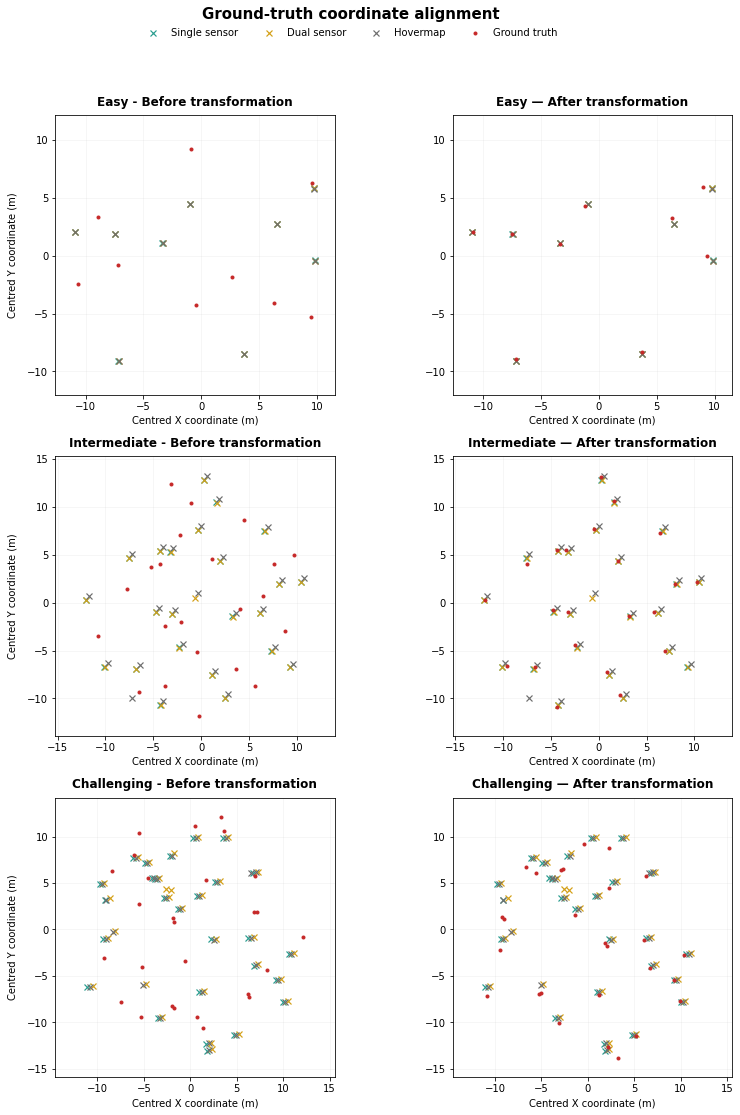

Saved: results/figures/gt_coordinate_alignment_before_after.png
Saved: results/figures/gt_coordinate_alignment_before_after.pdf


In [5]:
# # Plot the GT coordinates before and after alignment

import matplotlib.pyplot as plt
import numpy as np


# Plot colours
# Use the same colour for each scanner throughout the figure
scanner_colours = {
    "Single sensor": "#2A9D8F",   # teal
    "Dual sensor": "#D4A017",     # gold
    "Hovermap": "#6E6E6E",        # grey
}

gt_colour = "#C62828"            # red


terrains = [
    "Easy",
    "Intermediate",
    "Challenging",
]

scanners = [
    "Single sensor",
    "Dual sensor",
    "Hovermap",
]


# Create a 3 × 2 figure
# Each row represents one terrain
# The left column shows the original centred GT coordinates
# The right column shows the GT coordinates after alignment

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(13, 16),
)


# Plot each terrain

for row, terrain in enumerate(terrains):
    
    # Original centred GT coordinates and the transformed version
    gt_before = alignment_data[terrain]["GT"]
    gt_after = aligned_gt[terrain]

    # Set the same plotting limits for both panels
    # This means that any visual change is caused by the transformation and not a change in axis limits
    all_x = [
        gt_before["X_centred"].to_numpy(),
        gt_after["X_aligned"].to_numpy(),
    ]

    all_y = [
        gt_before["Y_centred"].to_numpy(),
        gt_after["Y_aligned"].to_numpy(),
    ]
    
    # Add the coordinates from all three scanner datasets
    for scanner in scanners:
        scanner_df = alignment_data[terrain][scanner]
        all_x.append(scanner_df["X_centred"].to_numpy())
        all_y.append(scanner_df["Y_centred"].to_numpy())
        
    # Combine all coordinate arrays into one X array and one Y array
    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)
    
    # Find the full spatial extent of the data
    x_min, x_max = all_x.min(), all_x.max()
    y_min, y_max = all_y.min(), all_y.max()
    
    # Calculate the centre of the plotting area
    x_mid = (x_min + x_max) / 2
    y_mid = (y_min + y_max) / 2
    
    # Use the larger of the X or Y ranges 
    # So that both axes cover the same distance and the plots remain spatially comparable
    max_span = max(x_max - x_min, y_max - y_min)
    half_span = max_span / 2
    
    # Add a small amount of space around the outermost trees
    pad = max(max_span * 0.08, 0.6)
    half_span_padded = half_span + pad

    x_limits = (
        x_mid - half_span_padded,
        x_mid + half_span_padded,
    )

    y_limits = (
        y_mid - half_span_padded,
        y_mid + half_span_padded,
    )

    
    # Left panel: before alignment

    ax_before = axes[row, 0]

    # Plot the centred positions from all three scanner datasets
    for scanner in scanners:
        scanner_df = alignment_data[terrain][scanner]

        ax_before.scatter(
            scanner_df["X_centred"],
            scanner_df["Y_centred"],
            marker="x",
            s=36,
            linewidths=1.2,
            color=scanner_colours[scanner],
            label=scanner,
            zorder=2,
        )
        
    # Add the original centred GT tree positions
    ax_before.scatter(
        gt_before["X_centred"],
        gt_before["Y_centred"],
        marker="o",
        s=9,
        color=gt_colour,
        label="Ground truth",
        zorder=3,
    )


    # Right panel: after alignment

    ax_after = axes[row, 1]
    
    # The scanner coordinates stay unchanged so that only the
    # effect of transforming the GT coordinates is being shown.
    for scanner in scanners:
        scanner_df = alignment_data[terrain][scanner]
        
    # Plot the transformed GT tree positions
        ax_after.scatter(
            scanner_df["X_centred"],
            scanner_df["Y_centred"],
            marker="x",
            s=36,
            linewidths=1.2,
            color=scanner_colours[scanner],
            zorder=2,
        )
        
    # Apply the same formatting to both panels
    ax_after.scatter(
        gt_after["X_aligned"],
        gt_after["Y_aligned"],
        marker="o",
        s=9,
        color=gt_colour,
        zorder=3,
    )


    # Apply the same formatting to both panels

    for ax in [ax_before, ax_after]:
        
        # Use the same X/Y limits before and after alignment
        ax.set_xlim(x_limits)
        ax.set_ylim(y_limits)

        # Keep each panel square so distances are represented consistently in the X and Y directions
        ax.set_box_aspect(1)

        ax.grid(alpha=0.18, linewidth=0.6)
        ax.set_xlabel("Centred X coordinate (m)", fontsize=10)
        ax.tick_params(labelsize=10)

    # Use a Y-axis label only on the left to avoid repetition
    ax_before.set_ylabel("Centred Y coordinate (m)", fontsize=10, labelpad=10)
    ax_after.set_ylabel("")

    ax_before.set_title(
        f"{terrain} - Before transformation",
        fontsize=12,
        fontweight="bold",
        pad=10,
    )

    ax_after.set_title(
        f"{terrain} — After transformation",
        fontsize=12,
        fontweight="bold",
        pad=10,
    )


# Add one shared legend for the full figure

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.985),
    fontsize=10,
)


fig.suptitle(
    "Ground-truth coordinate alignment",
    fontsize=15,
    fontweight="bold",
    y=0.995,
)

# Adjust the spacing, leave room for the title and legend
plt.tight_layout(
    rect=[0.08, 0.03, 1, 0.95]
)


# Save figure
# Save both a high-resolution PNG and a PDF version
FIGURE_DIR = PROJECT_DIR / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

png_path = FIGURE_DIR / "gt_coordinate_alignment_before_after.png"
pdf_path = FIGURE_DIR / "gt_coordinate_alignment_before_after.pdf"

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
)

plt.show()

# Print the saved file locations relative to the main project folder
print(f"Saved: {png_path.relative_to(PROJECT_DIR)}")
print(f"Saved: {pdf_path.relative_to(PROJECT_DIR)}")

In [6]:
# Save the aligned GT coordinates and alignment information

# Folder for the final transformed ground-truth coordinates:
PROCESSED_GT_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "ground_truth"
)
# Folder for the manual alignment choices, including the anchor-tree matches and whether reflection was applied:
ALIGNMENT_QC_DIR = (
    PROJECT_DIR
    / "data"
    / "manual_qc"
    / "coordinate_alignment"
)

# Folder for the final alignment summary table:
TABLE_DIR = (
    PROJECT_DIR
    / "results"
    / "tables"
)

# Create the output folders if they do not already exist
for directory in [
    PROCESSED_GT_DIR,
    ALIGNMENT_QC_DIR,
    TABLE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# Save the manual alignment choices

anchor_rows = []


for terrain, config in alignment_config.items():
    # Store the two GT-to-scanner anchor matches used for each
    # terrain, together with the reflection and scaling settings.
    anchor_rows.append(
        {
            "Terrain": terrain,
            "Reference_scanner": "Single sensor",
            "GT_anchor_1": config["gt_anchor_1"],
            "Scanner_anchor_1": config["scanner_anchor_1"],
            "GT_anchor_2": config["gt_anchor_2"],
            "Scanner_anchor_2": config["scanner_anchor_2"],
            "Reflect_X": config["reflect_xy"],
            "Reflect_Y": config["reflect_xy"],
            "Scaling_applied": False,
        }
    )

# Combine the alignment choices for all three terrains into one table
alignment_anchors = pd.DataFrame(
    anchor_rows
)


anchors_path = (
    ALIGNMENT_QC_DIR
    / "gt_alignment_anchors.csv"
)

alignment_anchors.to_csv(
    anchors_path,
    index=False,
)


# Save the transformed GT coordinates for each terrain

saved_gt_paths = []


for terrain in [
    "Easy",
    "Intermediate",
    "Challenging",
]:
    
    # Keep the original, centred, prepared and final aligned coordinates
    # So that each stage of the transformation can be checked later if needed
    gt_output = (
        aligned_gt[terrain][
            [
                "GT_ID",
                "X",
                "Y",
                "X_centred",
                "Y_centred",
                "X_prepared",
                "Y_prepared",
                "X_aligned",
                "Y_aligned",
            ]
        ]
        .copy()
    )

    # Rename the columns so the coordinate stage and units are clear in the saved CSV files
    gt_output = gt_output.rename(
        columns={
            "X": "X_raw_m",
            "Y": "Y_raw_m",
            "X_centred": "X_centred_m",
            "Y_centred": "Y_centred_m",
            "X_prepared": "X_prepared_m",
            "Y_prepared": "Y_prepared_m",
            "X_aligned": "X_aligned_m",
            "Y_aligned": "Y_aligned_m",
        }
    )

    # Add the terrain name as the first column
    gt_output.insert(
        0,
        "Terrain",
        terrain,
    )


    # Save one transformed GT file for each terrain
    output_path = (
        PROCESSED_GT_DIR
        / f"gt_transformed_{terrain.lower()}.csv"
    )


    gt_output.to_csv(
        output_path,
        index=False,
    )

    # Keep the path so all saved files can be listed at the end
    saved_gt_paths.append(
        output_path
    )


# Save the alignment settings and diagnostic checks
# Combine the manual alignment choices with the calculated rotation, anchor distances and remaining anchor errors
alignment_parameters = (
    alignment_anchors
    .merge(
        alignment_diagnostics,
        on="Terrain",
        how="left",
    )
)


parameters_path = (
    TABLE_DIR
    / "gt_alignment_parameters.csv"
)

alignment_parameters.to_csv(
    parameters_path,
    index=False,
)


# Print the locations of the saved files

print("Saved alignment provenance:")
print(
    f"  {anchors_path.relative_to(PROJECT_DIR)}"
)

print("\nSaved transformed GT coordinates:")

for path in saved_gt_paths:
    print(
        f"  {path.relative_to(PROJECT_DIR)}"
    )

print("\nSaved alignment diagnostics:")
print(
    f"  {parameters_path.relative_to(PROJECT_DIR)}"
)

Saved alignment provenance:
  data/manual_qc/coordinate_alignment/gt_alignment_anchors.csv

Saved transformed GT coordinates:
  data/processed/ground_truth/gt_transformed_easy.csv
  data/processed/ground_truth/gt_transformed_intermediate.csv
  data/processed/ground_truth/gt_transformed_challenging.csv

Saved alignment diagnostics:
  results/tables/gt_alignment_parameters.csv


In [7]:
# Final checks for the GT coordinate alignment
# Checking that the coordinate transformation has worked as expected for all three terrains
# The checks confirm that:
#   - the expected number of GT trees is still present
#   - each GT tree ID appears only once
#   - all aligned X/Y coordinates contain valid numeric values
#   - the calculated rotations match the values obtained previously
#   - the first anchor tree is aligned exactly with its scanner match
#   - distances between GT trees are unchanged by the rigid
#     transformation
# Because only reflection, rotation and translation are used, the spatial geometry of the GT tree map should be preserved

expected_counts = {
    "Easy": 9,
    "Intermediate": 22,
    "Challenging": 27,
}

# Rotation angles calculated previously for each terrain
# They are used here as an additional check that the transformation is being reproduced consistently
expected_rotations = {
    "Easy": 19.269103,
    "Intermediate": -17.602300,
    "Challenging": 30.854696,
}


audit_rows = []


for terrain in [
    "Easy",
    "Intermediate",
    "Challenging",
]:

    gt = aligned_gt[
        terrain
    ].copy()


    # Check the transformed GT data

    # Make sure no GT trees were lost during the transformation:
    assert len(gt) == expected_counts[terrain]
    
    # Each GT tree should occur only once:
    assert not gt["GT_ID"].duplicated().any()
    
    # Check that every final X/Y coordinate is a valid finite number:
    assert np.isfinite(
        gt[
            [
                "X_aligned",
                "Y_aligned",
            ]
        ].to_numpy()
    ).all()


    # Check that distances between GT trees are preserved

    # Coordinates before rotation and translation:
    before = gt[
        [
            "X_prepared",
            "Y_prepared",
        ]
    ].to_numpy()
    
    # Final aligned coordinates:
    after = gt[
        [
            "X_aligned",
            "Y_aligned",
        ]
    ].to_numpy()

    # Calculate the distance between every possible pair of GT trees before the transformation
    before_distances = np.sqrt(
        (
            (
                before[:, None, :]
                - before[None, :, :]
            ) ** 2
        ).sum(axis=2)
    )
    
    # Calculate the same pairwise distances after alignment
    after_distances = np.sqrt(
        (
            (
                after[:, None, :]
                - after[None, :, :]
            ) ** 2
        ).sum(axis=2)
    )

    # Find the largest change in distance between any tree pair
    # For a rigid transformation this should be zero
    max_distance_change = np.max(
        np.abs(
            before_distances
            - after_distances
        )
    )


    # Check the transformation results

    # Retrieve the diagnostics calculated earlier for this terrain:
    diagnostics = (
        alignment_diagnostics.loc[
            alignment_diagnostics["Terrain"]
            == terrain
        ]
        .iloc[0]
    )

    # Compare the calculated rotation with the value obtained previously for the same terrain:
    rotation_difference = abs(
        diagnostics["Rotation_deg"]
        - expected_rotations[terrain]
    )


    # The recalculated rotation should match to within 0.001 degrees
    assert rotation_difference < 0.001

    # Anchor 1 is used as the fixed point for translation,
    # So its remaining alignment error should be zero
    assert (
        diagnostics["First_anchor_error_m"]
        < 1e-10
    )

    # Reflection, rotation and translation should not change the distances between trees
    assert max_distance_change < 1e-10

    # Store the main checks for a final audit table
    audit_rows.append(
        {
            "Terrain": terrain,
            "N_GT": len(gt),
            "Rotation_deg":
                diagnostics["Rotation_deg"],
            "First_anchor_error_m":
                diagnostics["First_anchor_error_m"],
            "Second_anchor_error_m":
                diagnostics["Second_anchor_error_m"],
            "Max_pairwise_distance_change_m":
                max_distance_change,
            "Audit_passed": True,
        }
    )

# Combine the results from all three terrains into one table
alignment_audit = pd.DataFrame(
    audit_rows
)

# Save the audit table with the other alignment results
audit_path = (
    TABLE_DIR
    / "gt_alignment_audit.csv"
)

alignment_audit.to_csv(
    audit_path,
    index=False,
)

# Display the final alignment checks
print(
    alignment_audit.to_string(
        index=False,
        float_format=lambda x: f"{x:.10f}",
    )
)

print(
    "\nAll GT coordinate-alignment checks passed."
)

print(
    f"Saved: {audit_path.relative_to(PROJECT_DIR)}"
)

      Terrain  N_GT   Rotation_deg  First_anchor_error_m  Second_anchor_error_m  Max_pairwise_distance_change_m  Audit_passed
         Easy     9  19.2691031906          0.0000000000           0.0621010130                    0.0000000000          True
 Intermediate    22 -17.6022996916          0.0000000000           0.3155152008                    0.0000000000          True
  Challenging    27  30.8546961451          0.0000000000           0.1246443125                    0.0000000000          True

All GT coordinate-alignment checks passed.
Saved: results/tables/gt_alignment_audit.csv
